--- [FASE 1/5] SETUP E CONFIGURAZIONE ---
Setup completato. Percorsi trovati.

--- [FASE 2/5] CARICAMENTO DATI E MODELLI ---
Caricamento di tutti i dati (potrebbe richiedere un po' di tempo)...
  - Caricando fold1...
  - Caricando fold10...
  - Caricando fold2...
  - Caricando fold3...
  - Caricando fold4...
  - Caricando fold5...
  - Caricando fold6...
  - Caricando fold7...
  - Caricando fold8...
  - Caricando fold9...
Caricamento dati completato.
Creazione degli split di test...
Creato set di test con 1798 campioni.
Caricamento modelli...
Modelli e metadati caricati.

--- [FASE 3/5] ESECUZIONE PREDIZIONI ---
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Predizioni completate.

--- [FASE 4/5] CREAZIONE TABELLA COMPARATIVA ---

--- TABELLA RIASSUNTIVA DELLE PERFORMANCE SUL TEST SET ---
            Pipeline Accuracy F1-Score (Weighted)
Pipeline A (Log-Mel)   0.6146              0.6150
   Pipeline B (MFCC)   0.647

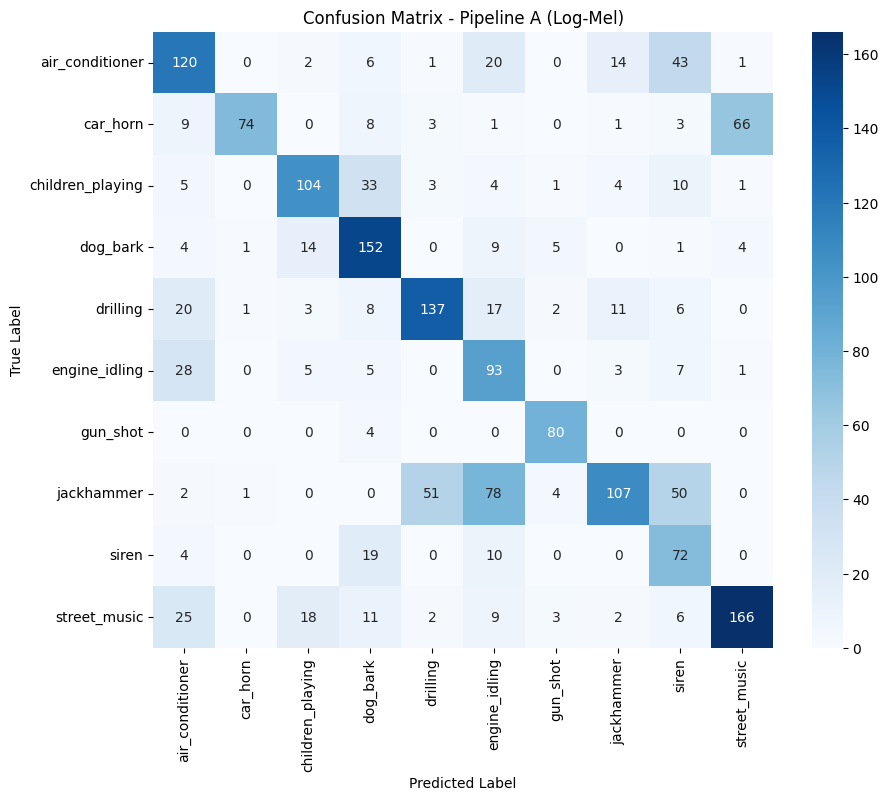

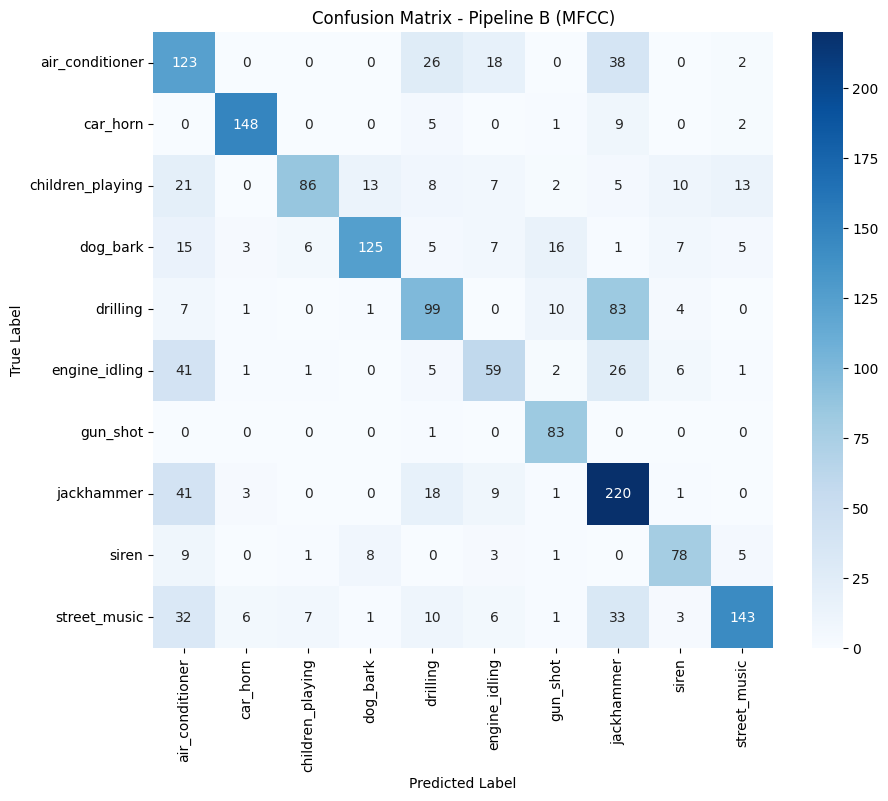

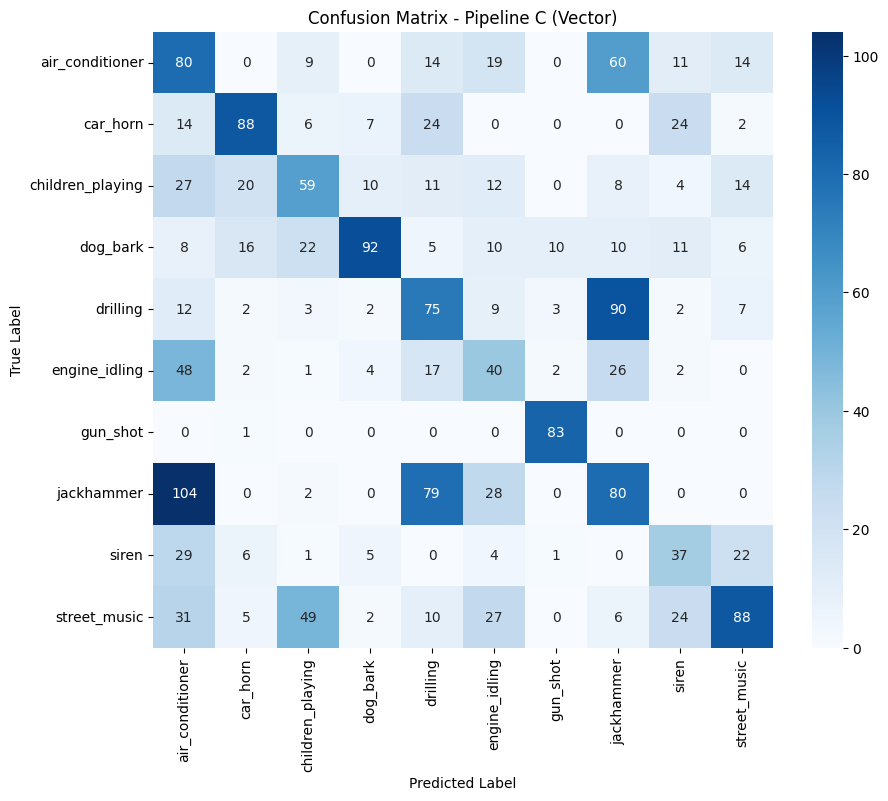

In [1]:
# ==============================================================================
# NOTEBOOK 05: COMPARAZIONE FINALE DEI MODELLI (PER ESECUZIONE LOCALE)
# ==============================================================================
# OBIETTIVO:
# 1. Caricare i tre modelli addestrati (A, B, C).
# 2. Caricare i dati di test corrispondenti a ogni tipo di feature.
# 3. Eseguire le predizioni su un set di test comune e coerente.
# 4. Generare una tabella comparativa delle performance (Accuracy, F1-Score).
# 5. Visualizzare le matrici di confusione per ogni modello.
# ==============================================================================

# --- 1. SETUP E CONFIGURAZIONE ---
print("--- [FASE 1/5] SETUP E CONFIGURAZIONE ---")

import os
import sys
import json
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score, accuracy_score

# Aggiunge la cartella radice del progetto al path per importare 'src'
# Funziona se il notebook è in 'progetto/notebooks/'
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src import data_loader, evaluation

# Percorsi relativi alla radice del progetto
MODELS_DIR = "../models"
FEATURES_DIR = "../data/processed/features"
CSV_PATH = "../data/raw/UrbanSound8K.csv" # Percorso al file CSV

# Verifica che i percorsi esistano
if not os.path.exists(MODELS_DIR) or not os.path.exists(FEATURES_DIR) or not os.path.exists(CSV_PATH):
    raise FileNotFoundError("Una delle cartelle/file necessari (models, features, UrbanSound8K.csv) non è stata trovata. Assicurati che il notebook sia nella cartella corretta.")

print("Setup completato. Percorsi trovati.")


# --- 2. CARICAMENTO DATI E MODELLI ---
print("\n--- [FASE 2/5] CARICAMENTO DATI E MODELLI ---")

# --- Logica di caricamento dati corretta e ottimizzata ---
# Carichiamo TUTTI i dati da tutti i fold una sola volta per ogni tipo di feature.
# Questo garantisce che lo split di test sia identico per tutti.

print("Caricamento di tutti i dati (potrebbe richiedere un po' di tempo)...")
all_data_logmel = {}
all_data_mfcc = {}
all_data_vector = {}
fold_dirs = sorted(glob.glob(os.path.join(FEATURES_DIR, "fold*")))

if not fold_dirs:
    raise FileNotFoundError(f"Nessuna cartella 'fold*' trovata in {FEATURES_DIR}.")

for fold_dir in fold_dirs:
    fold_name = os.path.basename(fold_dir)
    print(f"  - Caricando {fold_name}...")
    
    # Carica dati Log-Mel per il fold
    X_fold, y_fold = data_loader.collect_fold_data(fold_dir, data_loader.load_feature, feature_key='log_mel_spec')
    all_data_logmel[fold_name] = (X_fold, y_fold)

    # Carica dati MFCC per il fold (le etichette sono le stesse, quindi potremmo ottimizzare)
    X_fold, _ = data_loader.collect_fold_data(fold_dir, data_loader.load_feature, feature_key='mfcc')
    all_data_mfcc[fold_name] = (X_fold, y_fold)

    # Carica dati Vettoriali per il fold
    X_fold, _ = data_loader.collect_fold_data(fold_dir, data_loader.load_vector_features)
    all_data_vector[fold_name] = (X_fold, y_fold)

print("Caricamento dati completato.")

# Ora creiamo lo split di test per ogni tipo di feature, passando il percorso CSV corretto.
# Poiché usiamo lo stesso random_state di default (42), lo split sarà identico.
print("Creazione degli split di test...")
_, _, X_test_logmel, y_test = data_loader.get_train_test_split_from_folds(all_data_logmel, meta_file_path=CSV_PATH)
_, _, X_test_mfcc, _      = data_loader.get_train_test_split_from_folds(all_data_mfcc, meta_file_path=CSV_PATH)
_, _, X_test_vector, _    = data_loader.get_train_test_split_from_folds(all_data_vector, meta_file_path=CSV_PATH)
print(f"Creato set di test con {len(y_test)} campioni.")

# Caricamento dei modelli addestrati
print("Caricamento modelli...")
try:
    model_A = tf.keras.models.load_model(os.path.join(MODELS_DIR, "model_A_logmel.keras"))
    model_B = tf.keras.models.load_model(os.path.join(MODELS_DIR, "model_B_mfcc.keras"))
    model_C = tf.keras.models.load_model(os.path.join(MODELS_DIR, "model_C_vector.keras"))
except IOError as e:
    print(f"\nERRORE: Impossibile caricare uno dei modelli. Assicurati di aver eseguito tutti i notebook di addestramento.")
    print(f"Dettagli: {e}")
    # Esci o gestisci l'errore come preferisci
    sys.exit(1)

# Caricamento dei nomi delle classi da uno dei file di metadati
with open(os.path.join(MODELS_DIR, "model_A_logmel_metadata.json")) as f:
    class_map_from_json = json.load(f)['class_names']
class_labels = [class_map_from_json[str(i)] for i in sorted(class_map_from_json, key=lambda k: int(k))]
print("Modelli e metadati caricati.")


# --- 3. ESECUZIONE PREDIZIONI ---
print("\n--- [FASE 3/5] ESECUZIONE PREDIZIONI ---")
y_pred_A = np.argmax(model_A.predict(X_test_logmel), axis=1)
y_pred_B = np.argmax(model_B.predict(X_test_mfcc), axis=1)
y_pred_C = np.argmax(model_C.predict(X_test_vector), axis=1)
print("Predizioni completate.")


# --- 4. CREAZIONE TABELLA COMPARATIVA ---
print("\n--- [FASE 4/5] CREAZIONE TABELLA COMPARATIVA ---")
results = {
    "Pipeline A (Log-Mel)": y_pred_A,
    "Pipeline B (MFCC)": y_pred_B,
    "Pipeline C (Vector)": y_pred_C,
}

summary_data = []
for name, y_pred in results.items():
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    summary_data.append({"Pipeline": name, "Accuracy": f"{acc:.4f}", "F1-Score (Weighted)": f"{f1:.4f}"})

df_summary = pd.DataFrame(summary_data)
print("\n--- TABELLA RIASSUNTIVA DELLE PERFORMANCE SUL TEST SET ---")
print(df_summary.to_string(index=False))


# --- 5. VISUALIZZAZIONE MATRICI DI CONFUSIONE ---
print("\n--- [FASE 5/5] VISUALIZZAZIONE MATRICI DI CONFUSIONE ---")
# Assicurati che evaluation.plot_confusion_matrix sia definito e importato correttamente.
# Se non lo è, puoi usare la funzione qui sotto.

# Definiamo una funzione di plotting nel caso non sia in evaluation.py
def plot_local_confusion_matrix(y_true, y_pred, class_names, title):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

for name, y_pred in results.items():
    # Usa la tua funzione di plotting se esiste
    # evaluation.plot_confusion_matrix(y_test, y_pred, class_labels, title=f"Confusion Matrix - {name}")
    
    # O usa quella locale definita sopra
    plot_local_confusion_matrix(y_test, y_pred, class_labels, title=f"Confusion Matrix - {name}")

[Fase 1/4] Caricamento del modello e dei metadati...
Modello e metadati caricati con successo.


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 128, 173, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 128, 173, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 128, 173, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 64, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 64, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 86, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 64, 86, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 32, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 16, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 16, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_10 (Reshape)            │ (None, 21, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 256)            │     1,672,704 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,305,632 (20.24 MB)

 Trainable params: 1,768,394 (6.75 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 3,536,790 (13.49 MB)


[Fase 2/4] Preparazione del set di test...
Caricamento di tutti i dati per la feature: 'log_mel_spec'...
Set di test creato con 1798 campioni.

[Fase 3/4] Esecuzione delle predizioni e valutazione...
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step

--- PERFORMANCE REGISTRATA DURANTE IL TRAINING ---
  - Accuratezza: 0.6146
  - Loss: 1.1505

--- REPORT DI CLASSIFICAZIONE DETTAGLIATO (sul test set corrente) ---
                  precision    recall  f1-score   support

 air_conditioner       0.55      0.58      0.57       207
        car_horn       0.96      0.45      0.61       165
children_playing       0.71      0.63      0.67       165
        dog_bark       0.62      0.80      0.70       190
        drilling       0.70      0.67      0.68       205
   engine_idling       0.39      0.65      0.49       142
        gun_shot       0.84      0.95      0.89        84
      jackhammer       0.75      0.37      0.49       293
           siren       0.36      0.69      0.48       105
    street_mus

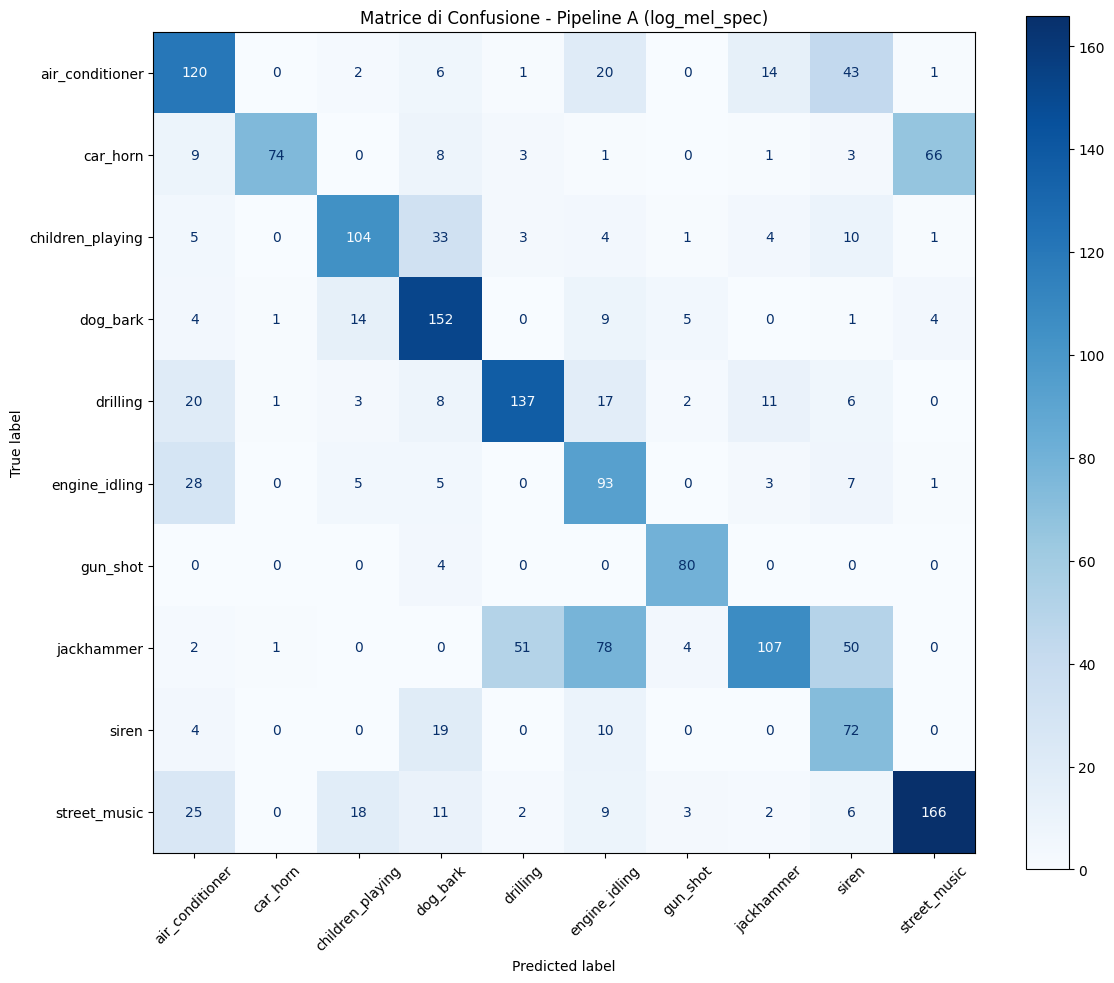


[Fase 4/4] Analisi degli errori più comuni...
Il modello ha commesso 693 errori su 1798 campioni di test.

Le 10 confusioni più frequenti:
true_label        predicted_label
jackhammer        engine_idling      78
car_horn          street_music       66
jackhammer        drilling           51
                  siren              50
air_conditioner   siren              43
children_playing  dog_bark           33
engine_idling     air_conditioner    28
street_music      air_conditioner    25
drilling          air_conditioner    20
air_conditioner   engine_idling      20


In [2]:
# ==============================================================================
# NOTEBOOK 05-A: ANALISI DETTAGLIATA DELLA PIPELINE A (LOG-MEL) - ESECUZIONE LOCALE
# ==============================================================================
# OBIETTIVO:
# 1. Caricare il modello finale e i metadati salvati dalla Pipeline A.
# 2. Ricreare l'esatto set di test usato durante l'addestramento.
# 3. Eseguire una valutazione approfondita.
# ==============================================================================

# --- 1. SETUP E IMPORT ---
import os
import sys
import json
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Aggiungi la cartella 'src' al path di sistema per permettere gli import
# Dato che il notebook è in 'notebooks/', dobbiamo salire di un livello ('..')
# per trovare la cartella 'src'.
module_path = os.path.abspath(os.path.join(os.path.dirname(__file__), '..')) if '__file__' in locals() else os.path.abspath(os.path.join(os.getcwd(), '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

try:
    from src import data_loader
except ImportError:
    print("ERRORE: Assicurati che la cartella 'src' esista al livello superiore della directory del progetto.")
    raise

# --- 2. CARICAMENTO MODELLO E METADATI ---
print("[Fase 1/4] Caricamento del modello e dei metadati...")

# I percorsi sono relativi alla root del progetto, quindi usiamo '..' per salire da 'notebooks/'
MODELS_DIR = "../models"
MODEL_FILENAME = "model_A_logmel.keras"
METADATA_FILENAME = "model_A_logmel_metadata.json"

model_path = os.path.join(MODELS_DIR, MODEL_FILENAME)
metadata_path = os.path.join(MODELS_DIR, METADATA_FILENAME)

try:
    model_A = tf.keras.models.load_model(model_path)
    with open(metadata_path, 'r') as f:
        metadata_A = json.load(f)
    print("Modello e metadati caricati con successo.")
    model_A.summary()
except Exception as e:
    raise FileNotFoundError(f"Errore: Assicurati che i file '{MODEL_FILENAME}' e '{METADATA_FILENAME}' esistano in '{MODELS_DIR}'.\n Dettagli: {e}")

# Estrai informazioni utili dai metadati
class_names_map = metadata_A['class_names']
class_labels = [class_names_map[str(i)] for i in range(len(class_names_map))]
feature_key = metadata_A.get('feature_key', 'log_mel_spec')

# --- 3. PREPARAZIONE DEL SET DI TEST ---
print("\n[Fase 2/4] Preparazione del set di test...")

FEATURES_DIR = "../data/processed/features"
META_FILE_PATH = "../data/raw/UrbanSound8K.csv"
RANDOM_STATE = 42 # Usa lo stesso random_state del training per riproducibilità

# Carica tutti i dati per la feature specifica
print(f"Caricamento di tutti i dati per la feature: '{feature_key}'...")
all_data = {}
fold_dirs = sorted(glob.glob(os.path.join(FEATURES_DIR, "fold*")))
for fold_dir in fold_dirs:
    fold_name = os.path.basename(fold_dir)
    X_fold, y_fold = data_loader.collect_fold_data(
        fold_dir, data_loader.load_feature, feature_key=feature_key
    )
    all_data[fold_name] = (X_fold, y_fold)

# Ricrea lo stesso identico split train/test
# Passiamo il percorso corretto del meta file alla funzione
_, _, X_test, y_test = data_loader.get_train_test_split_from_folds(
    all_data, meta_file_path=META_FILE_PATH, random_state=RANDOM_STATE
)
print(f"Set di test creato con {len(X_test)} campioni.")

# --- 4. VALUTAZIONE DEL MODELLO ---
print("\n[Fase 3/4] Esecuzione delle predizioni e valutazione...")

# Esegui predizioni
y_pred_proba = model_A.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# Valutazione generale con le metriche salvate nei metadati
final_perf = metadata_A['final_test_performance']
print("\n--- PERFORMANCE REGISTRATA DURANTE IL TRAINING ---")
print(f"  - Accuratezza: {final_perf['accuracy']:.4f}")
print(f"  - Loss: {final_perf['loss']:.4f}")

# Report di classificazione dettagliato
print("\n--- REPORT DI CLASSIFICAZIONE DETTAGLIATO (sul test set corrente) ---")
report = classification_report(y_test, y_pred, target_names=class_labels)
print(report)

# Matrice di confusione
print("\n--- MATRICE DI CONFUSIONE ---")
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    display_labels=class_labels,
    cmap='Blues',
    xticks_rotation=45
)
ax.set_title(f'Matrice di Confusione - Pipeline A ({feature_key})')
plt.tight_layout()
plt.show()

# --- 5. ANALISI DEGLI ERRORI ---
print("\n[Fase 4/4] Analisi degli errori più comuni...")

# Trova gli indici dei campioni classificati erroneamente
error_indices = np.where(y_pred != y_test)[0]
print(f"Il modello ha commesso {len(error_indices)} errori su {len(y_test)} campioni di test.")

# Crea un DataFrame per analizzare le confusioni
df_errors = pd.DataFrame({
    'true_label': [class_labels[i] for i in y_test[error_indices]],
    'predicted_label': [class_labels[i] for i in y_pred[error_indices]]
})

# Conta le confusioni più frequenti
error_counts = df_errors.groupby(['true_label', 'predicted_label']).size().sort_values(ascending=False)

print("\nLe 10 confusioni più frequenti:")
print(error_counts.head(10).to_string())